In [1]:
import numpy as np
import seaborn as sns
import sklearn.datasets

In [2]:
X, y = sklearn.datasets.make_moons(200, noise=0.15)

<Axes: >

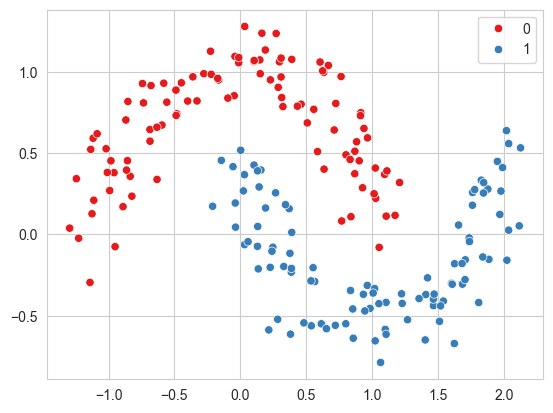

In [3]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1')

In [4]:
input_neurons = 2
output_neurons = 2
samples = len(X)
learning_rate = 0.001
lambda_reg = 0.01

In [5]:
def retrieve(model_dict):
    W1 = model_dict['W1']
    b1 = model_dict['b1']
    W2 = model_dict['W2']
    b2 = model_dict['b2']
    return W1, b1, W2, b2

In [6]:
def forward(X, model_dict):
    W1, b1, W2, b2 = retrieve(model_dict)
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = np.tanh(z2)
    exp_scores = np.exp(a2)
    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return z1, a1, softmax

In [7]:
def loss(softmax, y, model_dict):
    W1, b1, W2, b2 = retrieve(model_dict)
    softmax_loss = np.sum(-y * np.log(softmax[:,1]) - (1 - y) * np.log(softmax[:,0]))
    reg_Loss = lambda_reg / 2 * (np.sum(np.power(W1, 2)) + np.sum(np.power(W2, 2)))
    return float((softmax_loss + reg_Loss) / len(y))

In [8]:
def predict(X, model_dict):
    W1, b1, W2, b2 = retrieve(model_dict)
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = np.tanh(z2)
    exp_scores = np.exp(a2)
    softmax = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return np.argmax(softmax, axis=1)

In [9]:
def backpropagation(X, y, model_dict, epochs):
    for i in range(epochs):
        W1, b1, W2, b2 = retrieve(model_dict)
        z1, a1, probs = forward(X,model_dict)
        delta3 = np.copy(probs)
        delta3[range(X.shape[0]), y] -= 1                         # (200, 2) delta3 = probs - 1
        dw2 = a1.T @ delta3                                       # a1: (3, 200) @ (200, 2) -> (3, 2)
        db2 = np.sum(delta3, axis=0, keepdims=True)               # (1, 2)
        delta2 = delta3 @ W2.T * (1 - np.power(np.tanh(z1), 2))
        dw1 = X.T @ delta2
        db1 = np.sum(delta2, axis=0, keepdims=True)
        # Regularization
        dw2 += lambda_reg * np.sum(W2)
        dw1 += lambda_reg * np.sum(W1)
        # Update Weights
        W1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dw2
        b2 -= learning_rate * db2
        # Update Model
        model_dict = {
            'W1' : W1,
            'b1' : b1,
            'W2' : W2,
            'b2' : b2,
        }
        # Loss
        if i % 50 == 0:
            print(f"Loss at epoch {i}: {loss(probs, y, model_dict):.3f}")
    return model_dict

In [10]:
def init_network(input_dim, hidden_dim, output_dim):
    model = {}
    W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
    b2 = np.zeros((1, output_dim))
    model['W1'] = W1
    model['b1'] = b1
    model['W2'] = W2
    model['b2'] = b2
    return model

In [11]:
model_dict = init_network(input_neurons, 3, output_neurons)
model = backpropagation(X, y, model_dict, 1500)

Loss at epoch 0: 0.915
Loss at epoch 50: 0.356
Loss at epoch 100: 0.333
Loss at epoch 150: 0.341
Loss at epoch 200: 0.349
Loss at epoch 250: 0.355
Loss at epoch 300: 0.360
Loss at epoch 350: 0.362
Loss at epoch 400: 0.362
Loss at epoch 450: 0.360
Loss at epoch 500: 0.359
Loss at epoch 550: 0.357
Loss at epoch 600: 0.353
Loss at epoch 650: 0.346
Loss at epoch 700: 0.339
Loss at epoch 750: 0.330
Loss at epoch 800: 0.314
Loss at epoch 850: 0.306
Loss at epoch 900: 0.302
Loss at epoch 950: 0.299
Loss at epoch 1000: 0.299
Loss at epoch 1050: 0.299
Loss at epoch 1100: 0.300
Loss at epoch 1150: 0.302
Loss at epoch 1200: 0.305
Loss at epoch 1250: 0.307
Loss at epoch 1300: 0.310
Loss at epoch 1350: 0.313
Loss at epoch 1400: 0.316
Loss at epoch 1450: 0.319
